In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dlinear_disjoint = pd.read_csv("results/DLinear/rel_error_disjoint.csv")
dlinear_overlap = pd.read_csv("results/DLinear/rel_error.csv")
dlinear_ens_disjoint = pd.read_csv("results/DLinear/ensemble_32_20_disjoint_errors.csv")
dlinear_ens_overlap = pd.read_csv("results/DLinear/ensemble_32_20_overlapping_errors.csv")

In [3]:
dlinear_overlap.mean(numeric_only=True).round(3)

rel_normal       0.097
rel_abnormal     0.791
top1_normal      0.864
top1_abnormal    2.154
AUC-PR           0.486
AUC-ROC          0.809
Standard-F1      0.520
dtype: float64

In [4]:
dlinear_ens_overlap.mean(numeric_only=True).round(3)

rel_normal       0.019
rel_abnormal     0.159
top1_normal      0.175
top1_abnormal    0.433
AUC-PR           0.488
AUC-ROC          0.809
Standard-F1      0.522
dtype: float64

In [5]:
dlinear_disjoint.mean(numeric_only=True).round(3)

rel_normal        0.032
rel_abnormal      3.206
top1_normal       2.370
top1_abnormal    43.453
AUC-PR            0.420
AUC-ROC           0.763
Standard-F1       0.455
dtype: float64

In [6]:
dlinear_ens_disjoint.mean(numeric_only=True).round(3)

rel_normal       0.006
rel_abnormal     0.661
top1_normal      0.480
top1_abnormal    9.688
AUC-PR           0.439
AUC-ROC          0.777
Standard-F1      0.474
dtype: float64

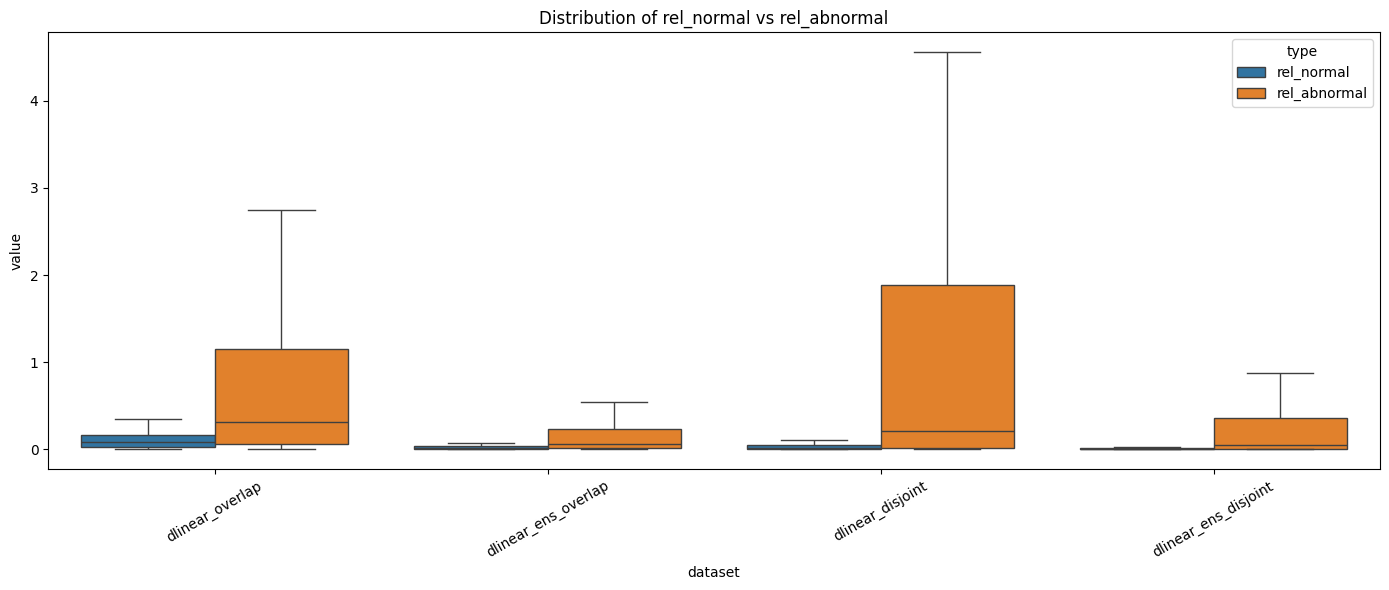

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dfs = {
    "dlinear_overlap": dlinear_overlap,
    "dlinear_ens_overlap": dlinear_ens_overlap,
    "dlinear_disjoint": dlinear_disjoint,
    "dlinear_ens_disjoint": dlinear_ens_disjoint
}

long_dfs = []

for name, df in dfs.items():
    tmp = df[["rel_normal", "rel_abnormal"]].melt(
        var_name="type",
        value_name="value"
    )
    tmp["dataset"] = name
    long_dfs.append(tmp)

plot_df = pd.concat(long_dfs, ignore_index=True)
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=plot_df,
    x="dataset",
    y="value",
    hue="type",
    showfliers=False  # cleaner if you have many outliers
)
#plt.yscale("log")
plt.xticks(rotation=30)
plt.title("Distribution of rel_normal vs rel_abnormal")
plt.tight_layout()
plt.show()

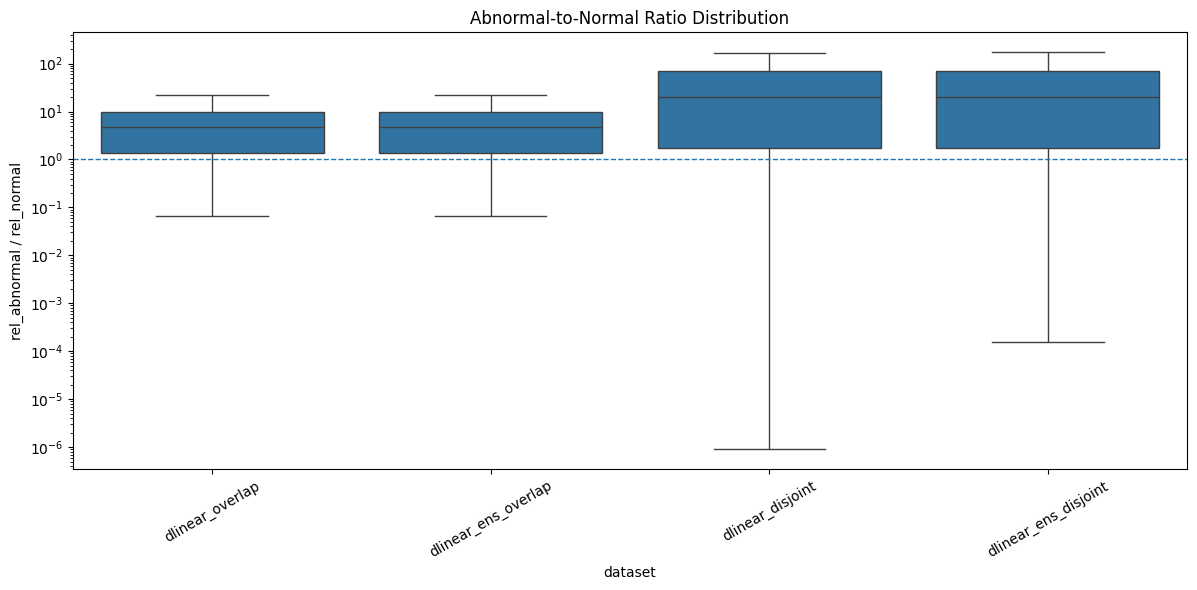

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dfs = {
    "dlinear_overlap": dlinear_overlap,
    "dlinear_ens_overlap": dlinear_ens_overlap,
    "dlinear_disjoint": dlinear_disjoint,
    "dlinear_ens_disjoint": dlinear_ens_disjoint
}

ratio_dfs = []

for name, df in dfs.items():
    tmp = pd.DataFrame({
        "ratio_abn_norm": df["rel_abnormal"] / df["rel_normal"]
    })
    tmp["dataset"] = name
    ratio_dfs.append(tmp)

ratio_df = pd.concat(ratio_dfs, ignore_index=True)
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=ratio_df,
    x="dataset",
    y="ratio_abn_norm",
    showfliers=False
)

plt.axhline(1.0, linestyle="--", linewidth=1)
plt.ylabel("rel_abnormal / rel_normal")
plt.xticks(rotation=30)
plt.title("Abnormal-to-Normal Ratio Distribution")
plt.tight_layout()
plt.yscale("log")
plt.show()

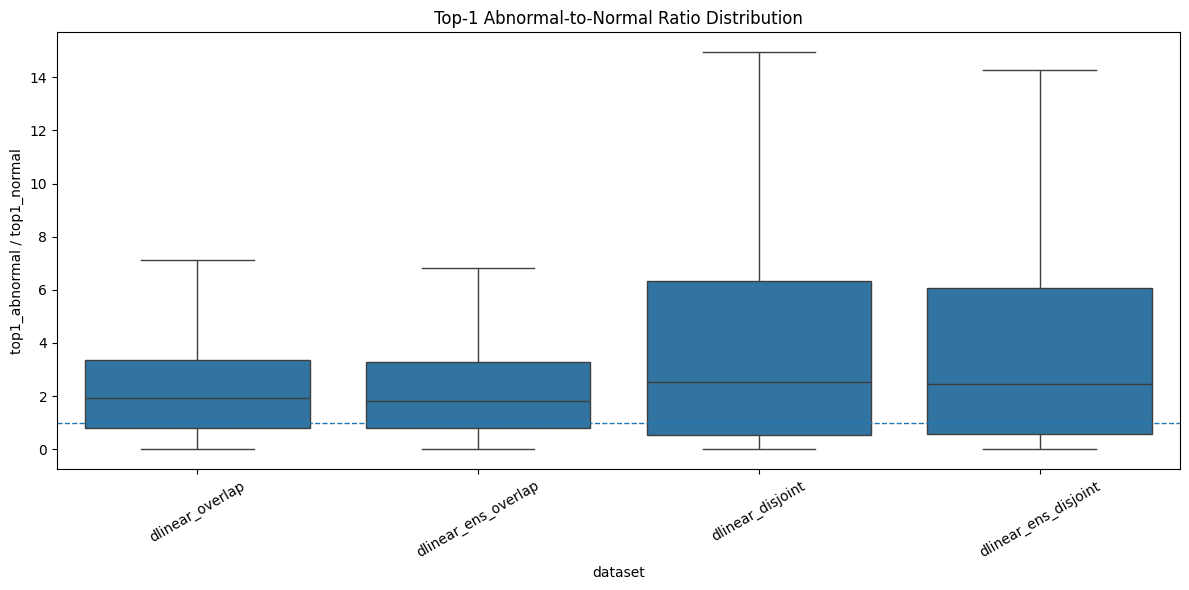

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dfs = {
    "dlinear_overlap": dlinear_overlap,
    "dlinear_ens_overlap": dlinear_ens_overlap,
    "dlinear_disjoint": dlinear_disjoint,
    "dlinear_ens_disjoint": dlinear_ens_disjoint
}

top1_ratio_dfs = []

for name, df in dfs.items():
    tmp = pd.DataFrame({
        "top1_ratio_abn_norm": df["top1_abnormal"] / df["top1_normal"].replace(0, pd.NA)
    })
    tmp["dataset"] = name
    top1_ratio_dfs.append(tmp)

top1_ratio_df = pd.concat(top1_ratio_dfs, ignore_index=True)
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=top1_ratio_df,
    x="dataset",
    y="top1_ratio_abn_norm",
    showfliers=False
)

plt.axhline(1.0, linestyle="--", linewidth=1)
plt.ylabel("top1_abnormal / top1_normal")
plt.xticks(rotation=30)
plt.title("Top-1 Abnormal-to-Normal Ratio Distribution")
plt.tight_layout()
plt.show()

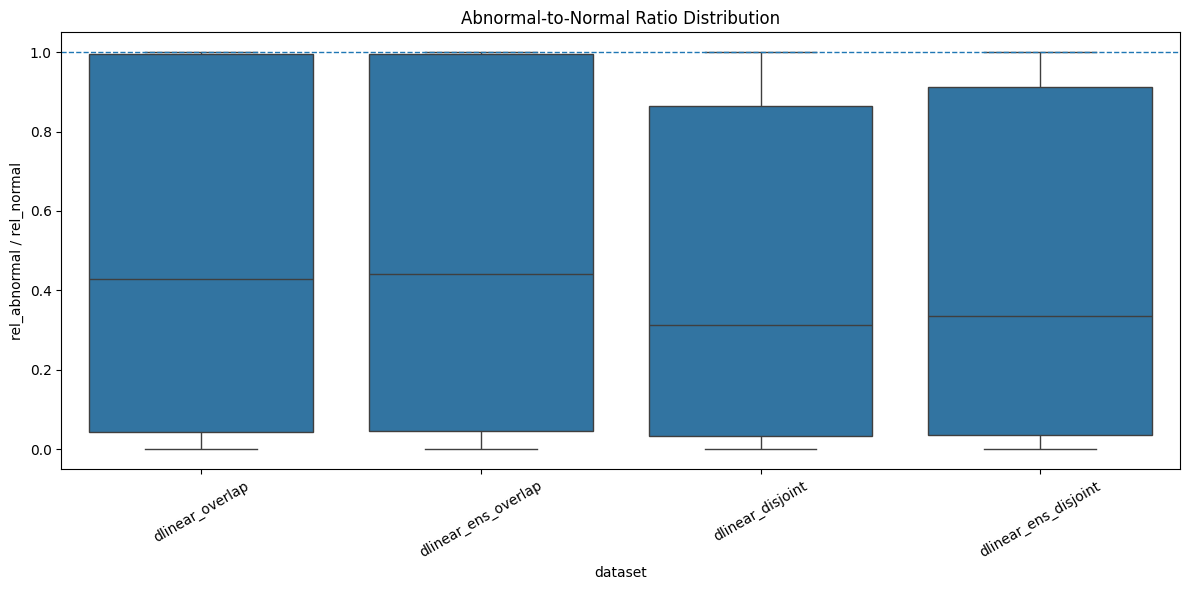

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dfs = {
    "dlinear_overlap": dlinear_overlap,
    "dlinear_ens_overlap": dlinear_ens_overlap,
    "dlinear_disjoint": dlinear_disjoint,
    "dlinear_ens_disjoint": dlinear_ens_disjoint
}

ratio_dfs = []

for name, df in dfs.items():
    tmp = pd.DataFrame({
        "AUC-PR": df["AUC-PR"]
    })
    tmp["dataset"] = name
    ratio_dfs.append(tmp)

ratio_df = pd.concat(ratio_dfs, ignore_index=True)
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=ratio_df,
    x="dataset",
    y="AUC-PR",
    showfliers=False
)

plt.axhline(1.0, linestyle="--", linewidth=1)
plt.ylabel("rel_abnormal / rel_normal")
plt.xticks(rotation=30)
plt.title("Abnormal-to-Normal Ratio Distribution")
plt.tight_layout()
#plt.yscale("log")
plt.show()

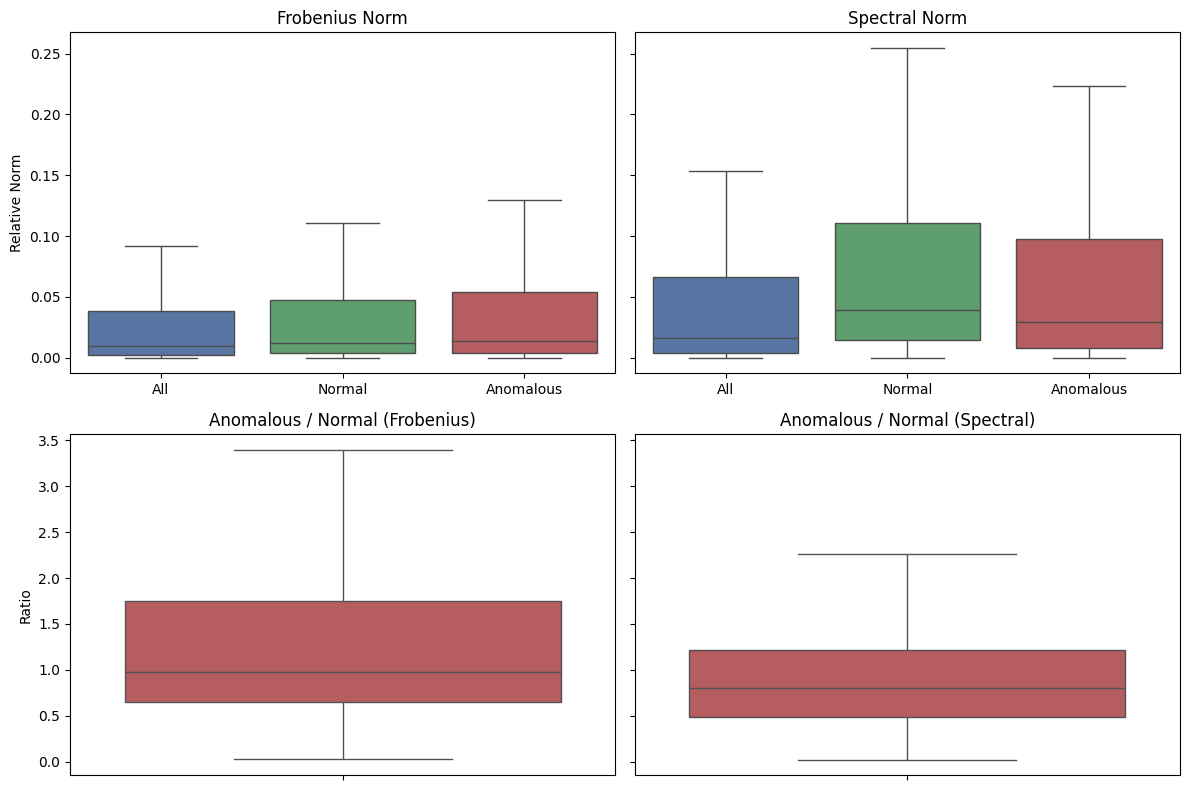

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("results/PCA/auto_all.csv")

fro_cols = [
    "relative_frobenius_norm",
    "normal_relative_frobenius_norm",
    "anomalous_relative_frobenius_norm"
]

spec_cols = [
    "relative_spectral_norm",
    "normal_relative_spectral_norm",
    "anomalous_relative_spectral_norm"
]

labels = ["All", "Normal", "Anomalous"]

# --- Prepare data for main plots ---
fro_df = df[fro_cols].copy()
fro_df.columns = labels
fro_df = fro_df.melt(var_name="Type", value_name="Value")

spec_df = df[spec_cols].copy()
spec_df.columns = labels
spec_df = spec_df.melt(var_name="Type", value_name="Value")

# --- Compute ratios ---
df["fro_ratio"] = df["anomalous_relative_frobenius_norm"] / df["normal_relative_frobenius_norm"]
df["spec_ratio"] = df["anomalous_relative_spectral_norm"] / df["normal_relative_spectral_norm"]

ratio_df = pd.DataFrame({
    "Frobenius Ratio": df["fro_ratio"],
    "Spectral Ratio": df["spec_ratio"]
}).melt(var_name="Norm", value_name="Ratio")

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(12,8), sharey='row')

palette = {
    "All": "#4C72B0",
    "Normal": "#55A868",
    "Anomalous": "#C44E52"
}

# Frobenius
sns.boxplot(
    data=fro_df,
    x="Type",
    y="Value",
    hue="Type",
    palette=palette,
    legend=False,
    ax=axes[0,0],
    showfliers=False
)

axes[0,0].set_title("Frobenius Norm")
axes[0,0].set_xlabel("")
axes[0,0].set_ylabel("Relative Norm")
#axes[0,0].set_yscale("log")

# Spectral
sns.boxplot(
    data=spec_df,
    x="Type",
    y="Value",
    hue="Type",
    palette=palette,
    legend=False,
    ax=axes[0,1],
    showfliers=False
)

axes[0,1].set_title("Spectral Norm")
axes[0,1].set_xlabel("")
axes[0,1].set_ylabel("")
#axes[0,1].set_yscale("log")

# Frobenius ratio
sns.boxplot(
    y=df["fro_ratio"],
    ax=axes[1,0],
    color="#C44E52",
    showfliers=False
)

axes[1,0].set_title("Anomalous / Normal (Frobenius)")
axes[1,0].set_ylabel("Ratio")
#axes[1,0].set_yscale("log")

# Spectral ratio
sns.boxplot(
    y=df["spec_ratio"],
    ax=axes[1,1],
    color="#C44E52",
    showfliers=False
)

axes[1,1].set_title("Anomalous / Normal (Spectral)")
axes[1,1].set_ylabel("")
#axes[1,1].set_yscale("log")

plt.tight_layout()
plt.show()

In [12]:
df.mean(numeric_only=True)

relative_frobenius_norm              0.035531
relative_spectral_norm               0.081870
normal_relative_frobenius_norm       0.043907
normal_relative_spectral_norm        0.095673
anomalous_relative_frobenius_norm    0.051877
anomalous_relative_spectral_norm     0.096613
AUC-PR                               0.176783
AUC-ROC                              0.644020
Standard-F1                          0.235205
dtype: float64